# PSYC 5P02- Introduction to Programming for Psychology
## Fall 2025

### Problem Set #4 - Grading Rubric

### Assigned November 14 25 - Due November 24
### Late Penalty: 5%/day


### Rubric:
* Accuracy & Efficiency: 50%
* Explaination and documentation: 50%

---

## **Question 1 --- Creating and Exploring Data with NumPy**

You will simulate data for **40 participants**, each completing **50 trials per condition** (100 trials total).

1.  Use NumPy to generate
    * Participant IDs (1-40)
    * Two Conditions: "congruent" and "incongruent"
    * Reaction times:
    - Congruent: mean = 520 ms, SD = 70 ms
    - Incongruent: mean 610 ms, SD = 70 ms
    * Add +/- 20ms uniformly distributed noise to all RTs
2.  Create a Pandas DataFrame with the columns: "participant", "condition", and "rt"
3.  Using the `df.head()` method and the df.describe(), display the first 10 rows of the DataFrame, and teh summary statistics

In [2]:

import numpy as np
import pandas as pd

# Set a random seed for reproducible results
np.random.seed(42)

#Create parameters for simulated data
num_participants = 40
trials_per_condition = 50
mean_c = 520
mean_ic = 610
sd = 70
noise_range = 20
total_trials = num_participants * trials_per_condition * 2

#Generate the simulated data

# Participant IDs (1-40 repeated for each condition and trial)
participant_ids = np.repeat(np.arange(1, num_participants + 1), trials_per_condition * 2)

# Conditions (alternating set of 50 congruent and incongruent for each participant)
conditions = np.tile(np.repeat(['congruent', 'incongruent'], trials_per_condition), num_participants)

# Generate RTs using boolean masking to assign samples
rts_base = np.zeros(total_trials) #np.zeros allows for providing a starting array that I will put the simulated data into
congruent_mask = (conditions == 'congruent')
incongruent_mask = (conditions == 'incongruent')

rts_base[congruent_mask] = np.random.normal(loc=mean_c, scale=sd, size=congruent_mask.sum()) #Generating the data, putting in my previously identified parameters
rts_base[incongruent_mask] = np.random.normal(loc=mean_ic, scale=sd, size=incongruent_mask.sum())

# Add uniformly distributed noise
noise = np.random.uniform(low=-noise_range, high=noise_range, size=total_trials) #generating noise, np.random.uniform to generate random numbers in a uniform distribution
rts = rts_base + noise #add da noise

#Generating the dataframe with pandas

data = {
    'participant': participant_ids,
    'condition': conditions,
    'rt': rts
}

df = pd.DataFrame(data)
print(df.head(10)) #printing the first 10 using .head
print(df.describe()) #describing the data using df.describe

   participant  condition          rt
0            1  congruent  554.170710
1            1  congruent  493.737620
2            1  congruent  584.236653
3            1  congruent  627.332507
4            1  congruent  508.176714
5            1  congruent  493.074804
6            1  congruent  629.884820
7            1  congruent  570.886411
8            1  congruent  470.132627
9            1  congruent  542.225617
       participant           rt
count   4000.00000  4000.000000
mean      20.50000   565.938003
std       11.54484    82.913731
min        1.00000   291.485032
25%       10.75000   509.376778
50%       20.50000   564.508691
75%       30.25000   624.793161
max       40.00000   872.022688


**Comments:**
- Good. Looks clean and efficient.  
- Code 6/6, documentation 6/6 **total: 12/12**

## **Question 2 --- Loading and Cleaning Data with Pandas**



1.  Using **indexing** (do NOT write a loop!), remove trials with RTs below 150 ms or above 1500 ms
2.  Print the number of trials removed.\
3.  Create a **cleaned DataFrame**. 
    * We didn't really cover this in class, so I'm going to give you the code, and you tell me what it's doing:


    `by_participant = clean_df.groupby(["participant", "condition"])["rt"].mean().reset_index()`


In [3]:

import numpy as ma
initial_trial_count = len(df) #collect intial count so I can later calculate total removed, probably there is a better way to do this, but this works
df = pd.DataFrame(data)
clean_df = (df ['rt'] >= 150) & (df['rt'] <= 1500) #using indexing to get rid of rts outside of parameters
final_trial_count = len(clean_df) #collecting new count
removed_trials_count = initial_trial_count - final_trial_count #calc for how many removed
print(removed_trials_count) 
cleaned_df = df[clean_df].copy()

by_participant = cleaned_df.groupby(["participant", "condition"])["rt"].mean().reset_index() # this line calcs mean of reaction times and organizes them based on groups (participants) 


0


**Comments:**
- Good. Not sure why you need `import numpy as ma` there (ma is never called). Also remember to add something to your print command so it's clear what's being printed (part of good documentation). Also, what does the `reset_index` do in the `groupby` command?
- code: 2/3, documentation 2/3, **total: 4/6**

## **Question 3 --- Merging DataFrames**

Using the cleaned data

1.  Compute the mean RT for each condition **without using `groupby`**.
    -   Hint: use boolean masks and `.mean()`.\
2.  Add a column called "accuracy", and add value of 1 or 0 to each trial, with a 80% chance of the value being a 1 (correct)\
3.  Re-calcualte the mean RT for each condition for only accurate trials. Feel free to use `groupby` for this. (**NOTE:** In class `groupby` was not working and we thought it was beause it was deprecated. It was only the `axis`` option that was deprecated. `groupby` appears to still very much be a useful tool.

In [4]:
#Question 3
mean_rt_congruent = df[congruent_mask]['rt'].mean() #calculating means for congruent conditions
mean_rt_incongruent = df[incongruent_mask]['rt'].mean() #calculating means for incongruent conditions
print(mean_rt_congruent) 
print(mean_rt_incongruent)

accuracy_chance = 0.8 # adding chance of getting accurate (=1) as 80%
df['accuracy'] = (np.random.rand(len(df)) < accuracy_chance).astype(int) #adds my new accuracy column, generates array (np.random.rand) (also same length as df), compares to accuracy_chance (previously identifed as 80%), lastly astype converts the true false response to 1s and 0s


# Filter df for only accurate trials
accurate_trials_df = df[df['accuracy'] == 1]
# Use groupby() to calculate the mean RT for each condition for accurate trials
mean_rts_by_condition_accurate = accurate_trials_df.groupby('condition')['rt'].mean()
print(mean_rts_by_condition_accurate)


522.7225429470348
609.1534620976602
condition
congruent      522.082898
incongruent    609.741832
Name: rt, dtype: float64


**comments:**
- Nice work. Again, be sure to document what is being printed with the print command.
- code: 6/6, documentation: 5/6 **total: 11/12**

## **Question 4 --- Plotting with Matplotlib**

Using the cleaned RT data from Question 2:

1.  Plot a histogram of RTs for each condition side-by-side (two subplots)\
2.  A mean RT bar graph (congruent vs. incongruent) with standard error error bars. (**Note:** you may need to look at the documentation for `matplotlib bar`) \
3.  Label axes clearly and give descriptive titles.
4.  Change at least 2 properties of the plots from the default options (i.e., colors, markers, axis labels, etc.)

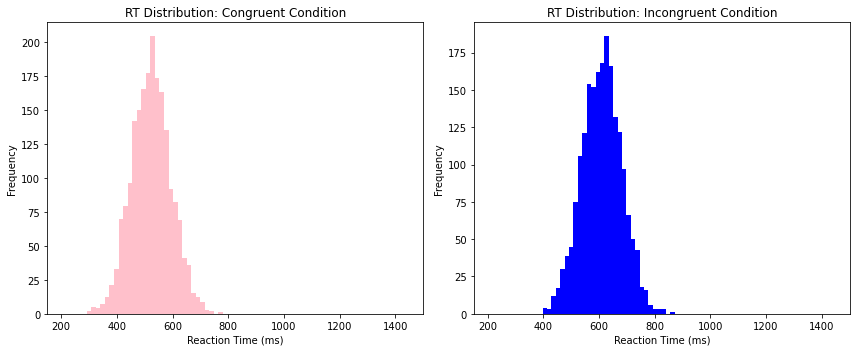

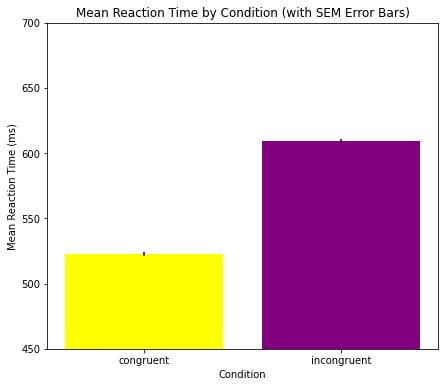

In [11]:
#Question 4
#create histogram of rts for each condition
import pandas as pd
import matplotlib.pyplot as plt #took me a while to figure out that spyder also allows for plot making, I thought I had to use jupiter notebooks, but this way everything is in the same place
rt_congruent = df[df['condition'] == 'congruent']['rt'] #allows me to separate conditions into two subplots
rt_incongruent = df[df['condition'] == 'incongruent']['rt']
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5)) #identifying size of figure
axes[0].hist(rt_congruent, bins=30, color = 'pink') #identifying that I want a histogram (.hist), for my congruent rts first, changed to color pink
axes[0].set_title('RT Distribution: Congruent Condition') #adding descriptive labels/titles for graph
axes[0].set_xlabel('Reaction Time (ms)')
axes[0].set_ylabel('Frequency')
axes[0].set_xlim(150, 1500) # Set reasonable axis limits, so the graph makes sense and looks nicer
axes[1].hist(rt_incongruent, bins=30, color='blue') #same with incongruent conditions, changed color to blue
axes[1].set_title('RT Distribution: Incongruent Condition')
axes[1].set_xlabel('Reaction Time (ms)')
axes[1].set_ylabel('Frequency') # Labeling both Y-axes
axes[1].set_xlim(150, 1500) # Set reasonable axis limits
plt.tight_layout() #not sure if this is needed, but as discussed in class it makes the titles seem to fit better
plt.show() 
#create mean rt bar graph 
import pandas as pd
import matplotlib.pyplot as plt # I dont think I have to out these in everytime but sometimes I dont put them and they don't work so I'm putting them just in case
summary_stats = df.groupby('condition')['rt'].agg(['mean', 'sem']).reset_index() #use group.by to calculate needed means 

plt.figure(figsize=(7, 6)) #identify size
plt.bar(
    summary_stats['condition'],          # X-axis labels
    summary_stats['mean'],              # Y-axis bar height (mean RT)
    yerr=summary_stats['sem'],          # Error bars using 'sem' column
    color=['yellow', 'purple']          # Change bar colors from default
)
plt.title('Mean Reaction Time by Condition (with SEM Error Bars)')
plt.xlabel('Condition')
plt.ylabel('Mean Reaction Time (ms)')
plt.ylim(450, 700) # Set a reasonable Y-limit so you can see everything properly
plt.show()


**Commnents:**
- Great! 
- code 6/6, documentation 6/6. **total: 12/12**

## **Question 5 --- Plotting with Seaborn**

Using Seaborn:

1.  Create a violin plot of RTs by condition. (You may need to look at the violin plot documentation)
2.  Create a line plot with condition on the x-axis and RT on the y axis, using different hues for each participant. 


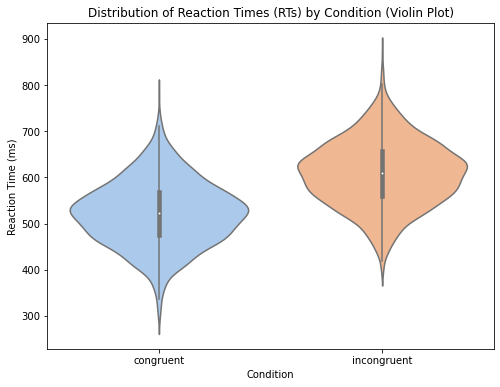

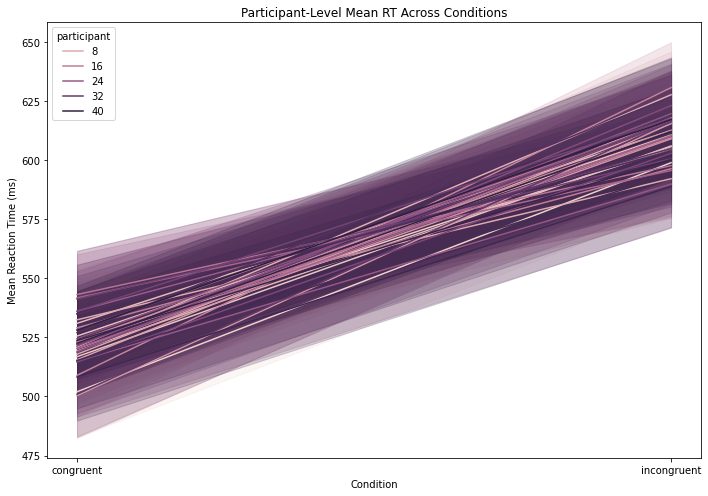

In [12]:
#Question 5 
#using seaborn to create fancy plots
#Violin plot
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.violinplot(
    data=df,         # identifying df containing the data
    x='condition',   # The column to use for the X-axis groups (Condition: Congruent/Incongruent)
    y='rt',          # The column to use for the Y-axis values (Reaction Times)
    palette='pastel'  #Using a fun color palette available through seaborn
)
#Labels and titles
plt.title('Distribution of Reaction Times (RTs) by Condition (Violin Plot)')
plt.xlabel('Condition')
plt.ylabel('Reaction Time (ms)')
plt.show()

#Line plot using different hues
#this one looks crazy

plt.figure(figsize=(10, 7)) #identifying size of graph

sns.lineplot(
    data=df,              # Identifying dataframe
    x='condition',        # X-axis: Condition: Congruent/Incongruent
    y='rt',               # Y-axis: Reaction Time 
    hue='participant',    # Using different hues for each participant ID
    dashes=False,         # Solid line instead of dotted one
)
#Labels and titles
plt.title('Participant-Level Mean RT Across Conditions')
plt.xlabel('Condition')
plt.ylabel('Mean Reaction Time (ms)')
plt.tight_layout() 
plt.show()


**Comments:**
- Good. (I wanted you to use the cleaned data from question 2, but I didn't make that clear).
- code: 3/3, documentation: 3/3, **total: 6/6**


## **Question 6 --- Curve Fitting: Visual Working Memory Capacity**

Researchers often measure visual working memory capacity (K) across
increasing memory loads.\
You are given:

    loads = np.array([1, 2, 3, 4, 5, 6])
    k = np.array([0.9000, 1.8000, 2.7000, 3.5000, 3.1966, 3.7939])

There are different models that describe the change in performance. One is a model that increases linearly up to a breakpoint (capacity limit), then stays flat.\

This is a model with **two stages**:

1.  **Linear growth stage:**\
    Performance increases steadily as memory load increases. 

2.  **Flat stage (capacity limit):**\
    After a certain point (the **breakpoint**), performance stops
    increasing because the memory system has reached its limit.\
    The breakpoint is the **estimated capacity**.


The model can be expressed as:

    if load ≤ k_break:
        y = a * load + b    # K is increasing with load
    else:
        y = a * k_break + b   # K stays constant

The second model is an exponential model. This model can be expressed as:



    y = A * (1 – exp(-B * load)) + C


  1. Fit both models to the data, where x is `load` and y is `k`. Report the relevant parameters for each model.  
  2. Plot both fits on the same Figure and subplot (do not use two subplots) using `matplotlib`


0.9000000000040567
-6.678812896121136e-12
3.8853703703561027
4.965350241114104
0.4083231363435147
-0.8175259652376898


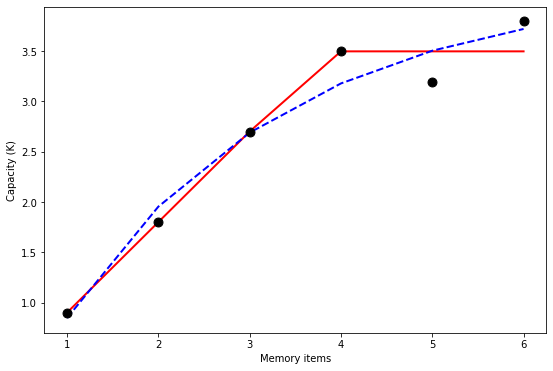

In [9]:

#Question 6
#not entirely sure how to approach this question, but I've taken a crack at it
#used a lot of online resources
#to start, I've approached trying to fit a flat stage model and a growth model to the data, to start we need to use scipy, which we used in class, but this one specifically for curve fit
import numpy as np
from scipy.optimize import curve_fit
#Given data
loads = np.array([1, 2, 3, 4, 5, 6])
k = np.array([0.9000, 1.8000, 2.7000, 3.5000, 3.1966, 3.7939])
#Flat stage model
def flat_model(x,a,b,k_break): #load now turns into x to be define by the function
    #y= a * x + b for x <= k_break, else y = a *k_break + b""" 
    return np.where(x <= k_break, a * x + b, a * k_break + b)
# Initial guess for parameters (slope ~1, intercept ~0, breakpoint or plateau? ~4)
p0_flat_model = [1.0, 0.0, 4.0] #found through stack overflow, but I don't super understand why it's needed, but I guess just as a starting point for the line fit
# Define bounds: a>0, b any real numeber, 1 < k_break < 6
bounds_flat_model = ([0, -np.inf, 1], [np.inf, np.inf, 6]) #similar to the intial guesses for values I guess the purpose of this is constraining the outcomes such that the slope is non-negative, intercept is a real number and the plateau is between 1 and 6, found through sub reddit r/learnpython "understanding curve_fit()"
params_fm, cov_fm = curve_fit(flat_model, loads, k, p0=p0_flat_model, bounds=bounds_flat_model) #applying to the curve fit to model
a_fm, b_fm, k_break_fm = params_fm #defining needed takeaway parameters
print(a_fm)
print(b_fm)
print(k_break_fm)

#do the same for other model
def growth_model(x, A, B, C):
    #y = A * (1 – exp(-B * x)) + C
    return A * (1 - np.exp(-B * x)) + C
p0_gm = [4.0, 0.5, 0.0]
params_gm, cov_gm = curve_fit(growth_model, loads, k, p0=p0_gm)
A_gm, B_gm, C_gm = params_gm
print(A_gm)
print(B_gm)
print(C_gm)

#plotting both fits on same figure
#really didn't know where to start here, found this through reading other peoples posts about trying to use curve fit to plot two models 
import matplotlib.pyplot as plt
#dealing with the x axis
x_fit = np.linspace(min(loads), max(loads), 100) #this is generating evenly spaced numbers spanning existing data point, x_fit is generating a smooth curve, curve_fit scipy manual had some helpful information as well as stack overflow

# Calculate y-values using the parameters from before
y_fit_fm = flat_model(x_fit, a_fm, b_fm, k_break_fm)
y_fit_gm = growth_model(x_fit, A_gm, B_gm, C_gm)

#creating a plot
#Im not sure that this graph looks right and I'm not sure why but it does make some kind of graph with a line fit
plt.figure(figsize=(9, 6))
# Plot original data points as a scatter plot to fit the line on to?
plt.scatter(loads, k, color='black', zorder=5, label='Observed Data', s=80)
# Plot the flat model fit line as line graph
plt.plot(x_fit, y_fit_fm, 'r-', linewidth=2, label=f'Flat Model Fit (K={k_break_lp:.2f})') #label with parameters
# Plot the growth mdoel fit line
plt.plot(x_fit, y_fit_gm, 'b--', linewidth=2, label='Growth Model Fit')
#Labels and titles
plt.xlabel('Memory items')
plt.ylabel('Capacity (K)')
plt.show()


**Comments:**
- code did not run in full. The problem was simply that `k_break_lp` needed to be switched to `k_break_fm`. 

```#Flat stage model
def flat_model(x,a,b,k_break): #load now turns into x to be define by the function
    #y= a * x + b for x <= k_break, else y = a *k_break + b""" 
    return np.where(x <= k_break, a * x + b, a * k_break + b)```
   
    
- I would like more explanation here of what this function is doing
- Overally not a ton of clarity from the comments. I can see you trying to work through the problem with some help, which is good, but it's not clear you fully understand everything here.


- code: 4/6, documentation: 3/6, **total: 7/12**

**Total grade: 54/60 - 5% 1 day late: 51/60**